Para ejercitarte y afianzar lo aprendido sobre **Redes Convolucionales**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
# filter warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split


## El problema de "Negocio"
Para este ejercicio vas a crear un clasificador automático de paisajes. Los datos los encontrarás en https://www.kaggle.com/datasets/puneet6060/intel-image-classification?select=seg_test como `seg_train.zip` y `seg_test.zip` (o bien en el botón de download).  

NOTA: Son archivos bastante grandes (386MB en total). Por supuesto, no es necesario que tengas que mantenerlos en tu ordenador una vez realizado el ejercicio, bórralos si es el caso.




### Ejercicio 1

Cargar las imágenes. Mira cómo están almacenados los datos. Tendrás que recorrer las carpetas, cargar las imágenes en memoria y etiquetarlas con los nombres de las carpetas. Realiza un reshape de cada imagen (comienza el ejercicio con 32x32, para ir más rápido en las ejecuciones). Para ello:

1. Descarga las imagenes del repositorio de Kaggle en el directorio que vayas a emplear para el ejercicio.
2. Descomprime los datos (son ficheros de imágenes) de forma que tengas dos subdirectorios seg_train y seg_test en el que estén ya colgando directamente los directorios de cada clase de paisajes. Si descargaste seg_pred, puedes eliminarlo.
3. Crea unas variables como las siguientes (ajustándolas a tu caso/rutas particulares):

```python
ROOT_PATH = './data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"
```
4. Utiliza la siguiente función para crear los X_train, y_train y X_test e y_test:

```python
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)
```


*Pues copiamos lo que nos dicen y lo aplicamos a los dos directorios para tener las X y las y*

In [2]:
import os
import cv2
from matplotlib.pyplot import imread

# 1. Definición de las variables de rutas
ROOT_PATH = "data/"
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

# 2. Función para leer y redimensionar las imágenes
def read_data(directorio, reshape_dim=(32, 32)):
    X = []
    y = []

    # Itera sobre las carpetas dentro del directorio principal
    for folder in os.listdir(directorio):
        folder_path = os.path.join(directorio, folder)

        if os.path.isdir(folder_path):
            # Itera sobre cada archivo de imagen dentro de la carpeta
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                # Lee la imagen y ajusta su tamaño usando OpenCV
                image = imread(file_path)
                image = cv2.resize(image, reshape_dim)

                # Agrega la matriz de la imagen a 'X' y su etiqueta a 'y'
                X.append(image)
                y.append(folder)

    # Devuelve los resultados convertidos en arrays de NumPy
    return np.array(X), np.array(y)



In [3]:
# 3. Creación de los conjuntos de datos de entrenamiento y prueba
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)

### Ejercicio 2

Haz la visualización del dataset: comprueba cuantos datos tienes, que forma, investiga las imágenes, comprueba con algunas muestras que has cargado bien los datos.


In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train)
print(y_test)

(14034, 32, 32, 3)
(3000, 32, 32, 3)
['buildings' 'buildings' 'buildings' ... 'street' 'street' 'street']
['buildings' 'buildings' 'buildings' ... 'street' 'street' 'street']


In [9]:
print(np.unique(y_train))

['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']


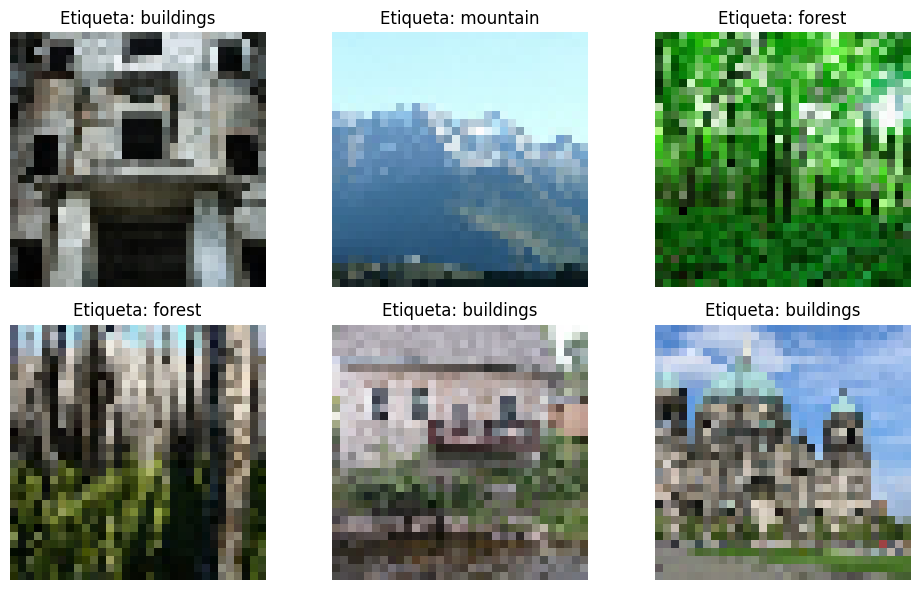

In [ ]:
fig, axes = plt.subplots(
    2,
    3, 
    figsize = (10,6))

for i, ax in enumerate (axes.flat):
    idx = np.random.randint(0, len(X_train), 6)[i] # Elegimos 6 índices al azar dentro del tamaño de nuestro set de entrenamiento
    ax.imshow(X_train[idx])
    ax.set_title(f"Etiqueta: {y_train[idx]}")
    ax.axis('off') # Ocultar los ejes (los números de los píxeles) para que quede limpio

plt.tight_layout()
plt.show() 

### Ejercicio 3

Ahora haz un pequeño miniEda y normaliza las features



In [12]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
# ==========================================
# 1. Mini EDA (Análisis Exploratorio)
# ==========================================

# Comprobar los valores mínimos y máximos actuales de los píxeles
print("--- Valores de los píxeles (Antes de normalizar) ---")
print(f"Mínimo: {X_train.min()}")
print(f"Máximo: {X_train.max()}\n")

--- Valores de los píxeles (Antes de normalizar) ---
Mínimo: 0
Máximo: 255



In [14]:
# Analizar la distribución de las clases para ver si el dataset está balanceado
clases, conteos = np.unique(y_train, return_counts=True)
df_distribucion = pd.DataFrame({'Clase': clases, 'Cantidad': conteos})
print("--- Distribución de clases (Train) ---")
print(df_distribucion)

--- Distribución de clases (Train) ---
       Clase  Cantidad
0  buildings      2191
1     forest      2271
2    glacier      2404
3   mountain      2512
4        sea      2274
5     street      2382


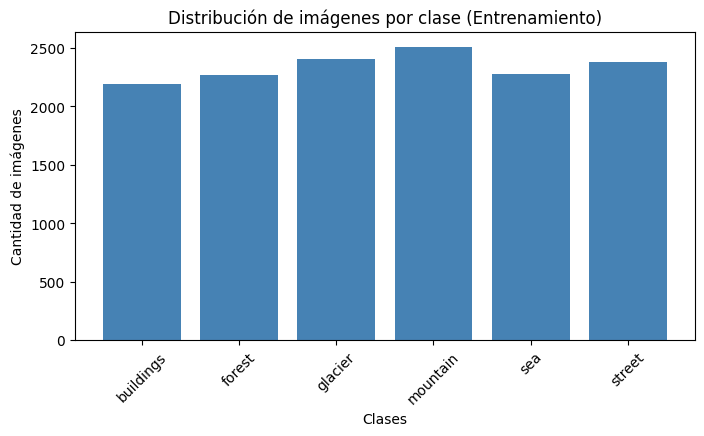

In [15]:
# Visualizar la distribución en un gráfico de barras
plt.figure(figsize=(8, 4))
plt.bar(clases, conteos, color='steelblue')
plt.title('Distribución de imágenes por clase (Entrenamiento)')
plt.xlabel('Clases')
plt.ylabel('Cantidad de imágenes')
plt.xticks(rotation=45)
plt.show()

In [16]:
# ==========================================
# 2. Normalización de Features y Etiquetas
# ==========================================

# Normalizar las features (X): 
# Las imágenes tienen valores de intensidad de 0 a 255. 
# Dividimos entre 255.0 para escalar los valores al rango [0, 1].
# Esto ayuda a que la red neuronal converja mucho más rápido durante el entrenamiento.
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("\n--- Valores de los píxeles (Después de normalizar) ---")
print(f"Mínimo: {X_train_norm.min()}")
print(f"Máximo: {X_train_norm.max()}\n")

# Codificar las etiquetas (y):
# Las redes neuronales no entienden texto (nombres de carpetas como 'bosque', 'montaña').
# Usamos LabelEncoder para transformar los strings en números enteros (0, 1, 2...).
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("--- Codificación de etiquetas ---")
print(f"Clases originales: {le.classes_}")
print(f"Mapeo numérico correspondiente: {np.arange(len(le.classes_))}")
print(f"Ejemplo de las primeras 5 etiquetas codificadas: {y_train_encoded[:5]}")


--- Valores de los píxeles (Después de normalizar) ---
Mínimo: 0.0
Máximo: 1.0

--- Codificación de etiquetas ---
Clases originales: ['buildings' 'forest' 'glacier' 'mountain' 'sea' 'street']
Mapeo numérico correspondiente: [0 1 2 3 4 5]
Ejemplo de las primeras 5 etiquetas codificadas: [0 0 0 0 0]


### Ejercicio 4

Diseña la arquitectura de la red. Recuerda que es un algiritmo de clasificación. Ojo con las dimensiones de la entrada. Como guía, copia o parte de la arquitectura del workout (un par de capas Conv2D + MaxPooling2D con activación relu y después la fully connected layer)


In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Calculamos el número de clases únicas (deberían ser 6 tipos de paisajes)
num_classes = len(np.unique(y_train))

# 1. Instanciamos el modelo secuencial
model = Sequential()

# 2. Primer bloque Convolucional + MaxPooling
# ¡Ojo con la entrada! Le decimos que las imágenes son de 32x32 píxeles y 3 canales (RGB)
model.add(Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3. Segundo bloque Convolucional + MaxPooling
# Aumentamos los filtros a 64 para que detecte patrones más complejos
model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 4. Capa Flatten (Aplanamiento)
# Convertimos el mapa de características 2D en un vector 1D para poder pasarlo a las capas densas
model.add(Flatten())

# 5. Capa oculta (Fully Connected / Densa)
model.add(Dense(units=128, activation='relu'))

# 6. Capa de salida
# Como es clasificación multiclase (varios paisajes), usamos 'softmax' para que nos devuelva probabilidades
model.add(Dense(units=num_classes, activation='softmax'))

# Mostramos el resumen de la arquitectura por pantalla
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 5

Escoge el resto de hiperparámetros (optimizador, learning_rate, función de pérdida, métrica,...) y compila el modelo. Muestra un resumen del mismo

In [18]:
from tensorflow.keras.optimizers import Adam

# 1. Definimos el optimizador y el learning rate
# Un learning rate de 0.001 es el "punto dulce" estándar para arrancar.
# Si lo pones muy alto, el modelo "derrapa" y no aprende (se salta el mínimo de error).
# Si lo pones muy bajo, aprenderá, pero tardará una eternidad.
optimizador = Adam(learning_rate=0.001)

# 2. Compilamos el modelo
model.compile(
    optimizer=optimizador,
    # OJO AQUÍ: Usamos 'sparse_categorical_crossentropy' porque en el Ejercicio 3
    # convertimos las etiquetas de texto a números enteros (0, 1, 2, 3...) con LabelEncoder.
    # Si hubiéramos hecho "One-Hot Encoding", usaríamos solo 'categorical_crossentropy'.
    loss='sparse_categorical_crossentropy',
    
    # Queremos que la métrica que nos muestre al entrenar sea la precisión (porcentaje de acierto)
    metrics=['accuracy'] 
)

# 3. Mostramos el resumen del modelo
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 315,206 (1.20 MB)

 Trainable params: 315,206 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 6

Entrena el modelo reservando un 20% de los datos del entrenamiento para validar y con los callbacks que creas necesarios. NOTA: Ojo, tendrás que preparar un poco los X,y antes.



In [19]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# 1. PREPARACIÓN DE LOS DATOS
# Separamos un 20% para validación, mezclando de forma aleatoria y estratificada
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_norm,       # Usamos las features normalizadas del Ejercicio 3
    y_train_encoded,    # Usamos las etiquetas numéricas del Ejercicio 3
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_encoded 
)

# 2. CONFIGURACIÓN DE CALLBACKS
# EarlyStopping detiene el entrenamiento si el modelo deja de mejorar, evitando el sobreajuste (overfitting).
early_stopping = EarlyStopping(
    monitor='val_loss',       # Vigilamos la función de pérdida en el conjunto de validación
    patience=3,               # Si tras 3 iteraciones (epochs) no mejora, corta el entrenamiento
    restore_best_weights=True # Se queda con los pesos de la mejor iteración, no con los de la última
)

# 3. ENTRENAMIENTO
# Guardamos el resultado en la variable 'history' para poder graficarlo en el siguiente ejercicio.
history = model.fit(
    X_train_final, 
    y_train_final,
    epochs=30,                # Ponemos un límite alto (ej. 30); el EarlyStopping lo parará antes si es necesario
    batch_size=32,            # Número de imágenes que pasan por la red antes de actualizar pesos
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5654 - loss: 1.1151 - val_accuracy: 0.6626 - val_loss: 0.9041
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6872 - loss: 0.8429 - val_accuracy: 0.7121 - val_loss: 0.7878
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7345 - loss: 0.7348 - val_accuracy: 0.6997 - val_loss: 0.8052
Epoch 4/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7537 - loss: 0.6685 - val_accuracy: 0.7317 - val_loss: 0.7483
Epoch 5/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7855 - loss: 0.5965 - val_accuracy: 0.7667 - val_loss: 0.6580
Epoch 6/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8026 - loss: 0.5497 - val_accuracy: 0.7738 - val_loss: 0.6432
Epoch 7/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8208 - loss: 0.5025 - val_accuracy: 0.7727 - val_loss: 0.6426
Epoch 8/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8379 - loss: 0.4525 - val_accuracy: 0.

### Ejercicio 7

Representa el objeto history y comenta la evolución de tu entrenamiento.



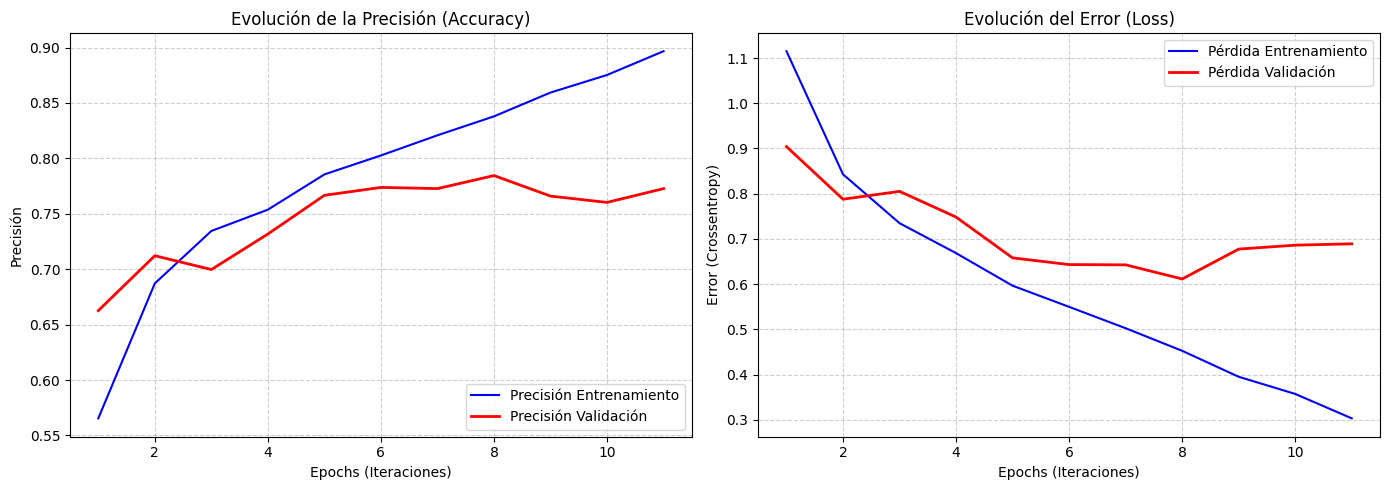

In [20]:
import matplotlib.pyplot as plt

# 1. Extraemos los datos registrados durante el entrenamiento
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# El número de vueltas (epochs) reales que ha dado antes de parar
epochs_range = range(1, len(acc) + 1)

# 2. Preparamos el panel de telemetría (2 gráficas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Precisión (¿Cuántas fotos acierta?)
ax1.plot(epochs_range, acc, 'b-', label='Precisión Entrenamiento')
ax1.plot(epochs_range, val_acc, 'r-', linewidth=2, label='Precisión Validación')
ax1.set_title('Evolución de la Precisión (Accuracy)')
ax1.set_xlabel('Epochs (Iteraciones)')
ax1.set_ylabel('Precisión')
ax1.legend(loc='lower right')
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfica 2: Pérdida (¿Cuánto se equivoca / Nivel de error?)
ax2.plot(epochs_range, loss, 'b-', label='Pérdida Entrenamiento')
ax2.plot(epochs_range, val_loss, 'r-', linewidth=2, label='Pérdida Validación')
ax2.set_title('Evolución del Error (Loss)')
ax2.set_xlabel('Epochs (Iteraciones)')
ax2.set_ylabel('Error (Crossentropy)')
ax2.legend(loc='upper right')
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Ejercicio 8

Evalua el modelo con los datos de test, además muestra el report de clasificación y la matriz de confusión.



--- Evaluación en el conjunto de Test ---
Precisión (Accuracy) en Test: 77.23%
Pérdida (Loss) en Test: 0.6307

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
--- Reporte de Clasificación ---
              precision    recall  f1-score   support

   buildings       0.76      0.69      0.72       437
      forest       0.89      0.92      0.90       474
     glacier       0.76      0.68      0.72       553
    mountain       0.69      0.82      0.75       525
         sea       0.76      0.72      0.74       510
      street       0.79      0.81      0.80       501

    accuracy                           0.77      3000
   macro avg       0.78      0.77      0.77      3000
weighted avg       0.77      0.77      0.77      3000

--- Generando Matriz de Confusión ---


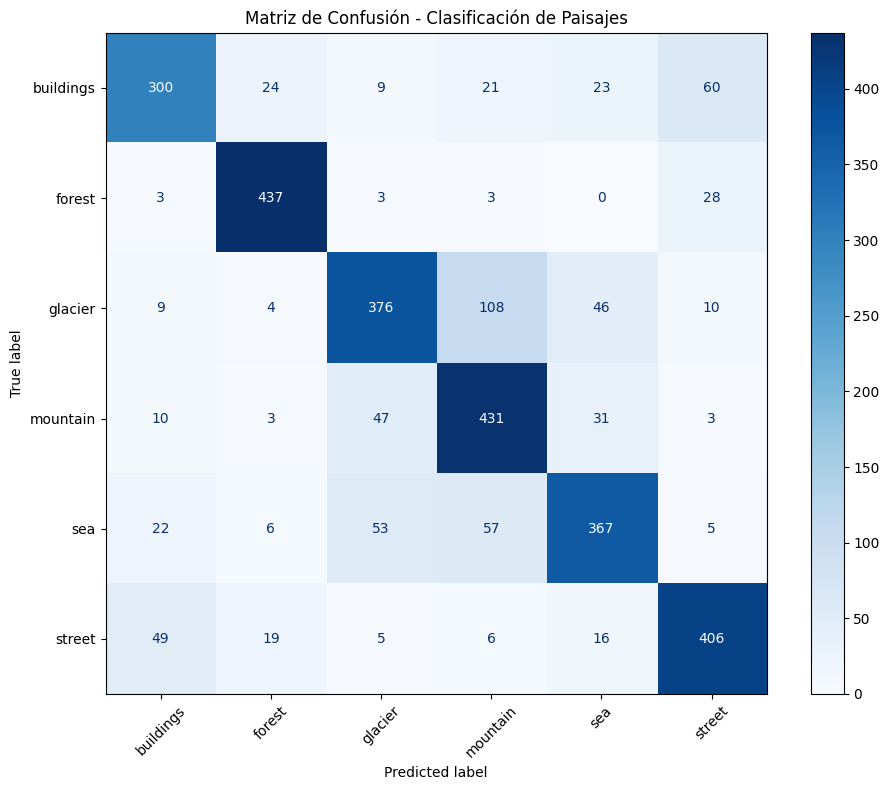

In [21]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Evaluación general (Tiempo de vuelta rápido)
print("--- Evaluación en el conjunto de Test ---")
test_loss, test_acc = model.evaluate(X_test_norm, y_test_encoded, verbose=0)
print(f"Precisión (Accuracy) en Test: {test_acc * 100:.2f}%")
print(f"Pérdida (Loss) en Test: {test_loss:.4f}\n")

# 2. Predicciones
# El modelo devuelve probabilidades para cada clase (softmax). 
# Con argmax nos quedamos con el índice de la clase con mayor probabilidad.
y_pred_probs = model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Reporte de Clasificación (Telemetría detallada)
print("--- Reporte de Clasificación ---")
# Usamos le.classes_ (del Ejercicio 3) para que nos ponga el nombre de los paisajes, no números
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

# 4. Matriz de Confusión
print("--- Generando Matriz de Confusión ---")
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test_encoded, 
    y_pred, 
    display_labels=le.classes_, 
    cmap='Blues', 
    ax=ax,
    xticks_rotation=45 # Rotamos las etiquetas para que se lean bien
)
ax.set_title('Matriz de Confusión - Clasificación de Paisajes')
plt.tight_layout()
plt.show()


### Ejercicio 9 

Representa algunos de los paisajes donde el modelo comete errores y muestra la confianza que tenía en ellos.

Total de errores cometidos: 683 de 3000 imágenes.


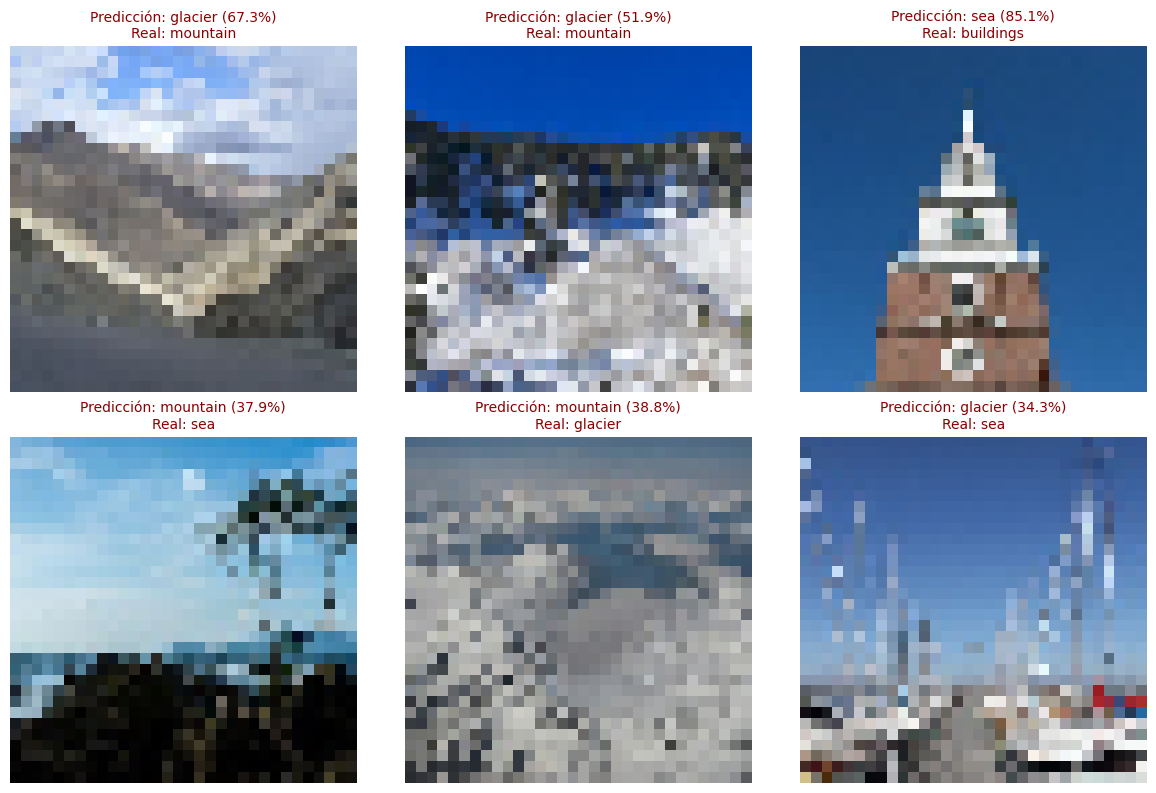

In [22]:
# 1. Localizar los índices donde la predicción no coincide con la realidad
errores_idx = np.where(y_pred != y_test_encoded)[0]

print(f"Total de errores cometidos: {len(errores_idx)} de {len(y_test_encoded)} imágenes.")

# 2. Seleccionar 6 errores al azar para visualizarlos
num_muestras = min(6, len(errores_idx))
muestras_errores = np.random.choice(errores_idx, size=num_muestras, replace=False)

# 3. Configurar el panel de visualización
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat):
    if i < num_muestras:
        idx = muestras_errores[i]
        
        # Recuperamos la imagen original normalizada
        imagen = X_test_norm[idx]
        
        # Recuperamos los nombres en texto de la clase real y la predicha
        etiqueta_real = le.inverse_transform([y_test_encoded[idx]])[0]
        etiqueta_pred = le.inverse_transform([y_pred[idx]])[0]
        
        # Calculamos la confianza (el porcentaje de seguridad que tenía al equivocarse)
        confianza = y_pred_probs[idx][y_pred[idx]] * 100
        
        # Pintamos la imagen
        ax.imshow(imagen)
        
        # Añadimos la información al título
        titulo = f"Predicción: {etiqueta_pred} ({confianza:.1f}%)\nReal: {etiqueta_real}"
        ax.set_title(titulo, color='darkred', fontsize=10)
        ax.axis('off')
    else:
        ax.axis('off') # Por si hay menos de 6 errores, ocultamos el hueco vacío

plt.tight_layout()
plt.show()

### Ejercicio EXTRA: 

Aumenta la resolución y repite el ejercicio con la misma topología de red

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

print("1. Recargando imágenes a 64x64 píxeles...")
NUEVA_DIMENSION = (64, 64)

# Reutilizamos la función del Ejercicio 1
X_train_alta, _ = read_data(TRAIN_PATH, reshape_dim=NUEVA_DIMENSION)
X_test_alta, _ = read_data(TEST_PATH, reshape_dim=NUEVA_DIMENSION)

# Normalizamos dividiendo entre 255
X_train_alta_norm = X_train_alta.astype('float32') / 255.0
X_test_alta_norm = X_test_alta.astype('float32') / 255.0

print("2. Haciendo el split de validación...")
# Reutilizamos las etiquetas codificadas (y_train_encoded) del Ejercicio 3
X_train_final_alta, X_val_alta, y_train_final_alta, y_val_alta = train_test_split(
    X_train_alta_norm,       
    y_train_encoded, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_encoded 
)

print("3. Construyendo la red con la nueva entrada (64x64x3)...")
model_alta = Sequential()
model_alta.add(Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)))
model_alta.add(MaxPooling2D((2, 2)))
model_alta.add(Conv2D(64, (3, 3), activation='relu'))
model_alta.add(MaxPooling2D((2, 2)))
model_alta.add(Flatten())
model_alta.add(Dense(128, activation='relu'))
model_alta.add(Dense(num_classes, activation='softmax'))

model_alta.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("4. Entrenando el modelo...")
history_alta = model_alta.fit(
    X_train_final_alta, 
    y_train_final_alta,
    epochs=30,                
    batch_size=32,            
    validation_data=(X_val_alta, y_val_alta),
    callbacks=[early_stopping], # Reutilizamos el early_stopping del Ejercicio 6
    verbose=1
)

print("\n--- 5. Evaluación Final en Test (64x64) ---")
test_loss_alta, test_acc_alta = model_alta.evaluate(X_test_alta_norm, y_test_encoded, verbose=0)
print(f"Precisión (Accuracy) con 64x64: {test_acc_alta * 100:.2f}%")

1. Recargando imágenes a 64x64 píxeles...
2. Haciendo el split de validación...
3. Construyendo la red con la nueva entrada (64x64x3)...
4. Entrenando el modelo...
Epoch 1/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6289 - loss: 0.9747 - val_accuracy: 0.7228 - val_loss: 0.7577
Epoch 2/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7534 - loss: 0.6832 - val_accuracy: 0.7602 - val_loss: 0.6702
Epoch 3/30
351/351 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.8081 - loss: 0.5319 - val_accuracy: 0.7912 - val_loss: 0.6181

--- 5. Evaluación Final en Test (64x64) ---
Precisión (Accuracy) con 64x64: 72.10%
